In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [14]:
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target
class_names = iris.target_names

In [15]:
# Binarize the output for ROC (multiclass)
y_bin = label_binarize(y, classes=[0, 1, 2])
n_classes = y_bin.shape[1]


In [16]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.3, random_state=42)

In [17]:
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
# Naive Bayes classifier (Gaussian)
model = OneVsRestClassifier(GaussianNB())
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [19]:
# Convert one-hot to class labels
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

In [20]:
# Evaluation metrics
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

accuracy = accuracy_score(y_test_labels, y_pred_labels)
error_rate = 1 - accuracy

print(f"Accuracy: {accuracy:.4f}")
print(f"Error Rate: {error_rate:.4f}")


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.85      0.92        13
   virginica       0.76      1.00      0.87        13

   micro avg       0.91      0.96      0.93        45
   macro avg       0.92      0.95      0.93        45
weighted avg       0.93      0.96      0.94        45
 samples avg       0.92      0.96      0.93        45

Accuracy: 0.9556
Error Rate: 0.0444


C:\Users\JOSHUA MUTUNGA\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [21]:
# Confusion matrix (for each class)
for i in range(n_classes):
    cm = confusion_matrix(y_test[:, i], y_pred[:, i])
    print(f"Confusion Matrix for class {class_names[i]}:\n{cm}\n")

Confusion Matrix for class setosa:
[[26  0]
 [ 0 19]]

Confusion Matrix for class versicolor:
[[32  0]
 [ 2 11]]

Confusion Matrix for class virginica:
[[28  4]
 [ 0 13]]



In [22]:
# Convert predictions and true labels back from one-hot
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

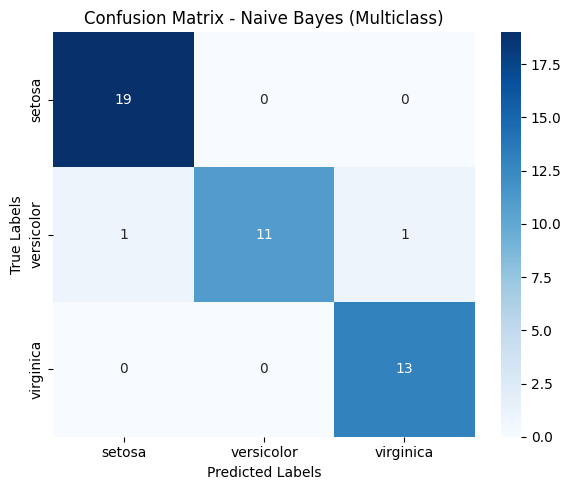

In [23]:
# Generate confusion matrix
cm = confusion_matrix(y_test_labels, y_pred_labels)

# Plot with seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Naive Bayes (Multiclass)')
plt.tight_layout()
plt.show()

In [24]:
# ROC Curve
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

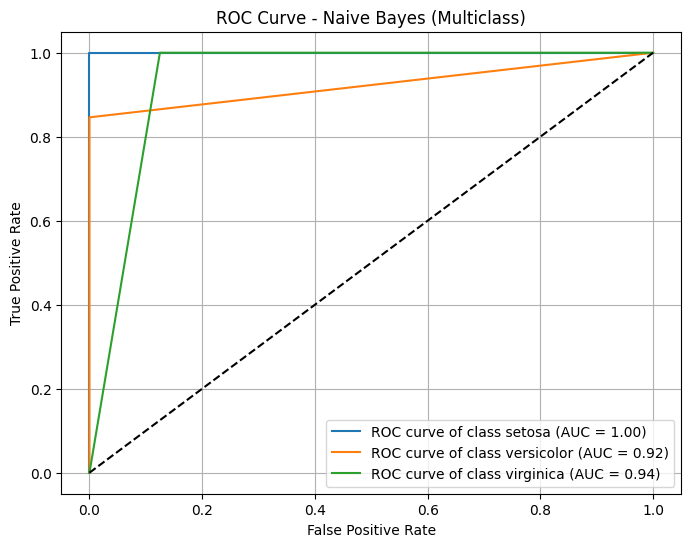

In [25]:
# Plot ROC Curve
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {class_names[i]} (AUC = {roc_auc[i]:0.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes (Multiclass)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [26]:
import joblib
from sklearn.preprocessing import StandardScaler

# X_train and X_test
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Save the model and scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

joblib.dump(scaler, 'scaler.pkl')


joblib.dump(model, 'naive_bayes_model.pkl')

print("Model saved successfully as 'naive_bayes_model.pkl'")



Model saved successfully as 'naive_bayes_model.pkl'
